# High-Level Routines: Qubricks

In this tutorial, we will introduce routines that describe higher-level building blocks of quantum algorithms.
In Workbench, they are called Qubricks (short for "quantum bricks").

## Core features of Qubricks

* High-level abstraction. You can write high-level quantum code by relying on libraries of commonly used building blocks of algorithms. For example, you can use an adder Qubrick instead of writing out the entire sequence of gates every time you need to add two quantum numbers.
* [Automatic uncomputation](./Qubricks-Uncomputation.ipynb). Quantum algorithms often rely on uncomputing parts of earlier computation. Implementing uncomputation by hand is cumbersome and error-prone. When you implement your computation as a Qubrick, Workbench manages its uncomputation automatically.
* [Simplified auxiliary qubit management](./Qubricks-Qubit-Management.ipynb). Most routines in quantum algorithms rely on allocating auxiliary qubits. Keeping track of quantum memory needs of each subroutine of a high-level algorithm can be tricky, since they can vary between different subroutines performing the same task. Workbench manages qubit allocation and release within Qubrick automatically.

We will go through each of these core features in the later tutorials. In this tutorial, we will focus on introducing the concept of Qubricks, the basics of defining and using them, and go through several simple examples.


## Defining Qubricks

To define a Qubrick, you have to implement a class which is a subclass of class `Qubrick`. This base class implements the fundamental mechanisms necessary for automatic uncomputation, auxiliary qubit management, and other Qubrick capabilities. These mechanisms are shared by all Qubricks.

The logic of the computation performed by each Qubrick is defined by implementing several methods of this class.

### The _compute method

The `_compute` method contains the core logic of performing the quantum routine defined by a Qubrick. 

For example, for a state preparation Qubrick, this method will take a Qubits object and a description of a quantum state as the inputs and prepare the described state on the given qubit register. For an adder Qubrick, this method will take two Qubits objects and perform addition on them, and so on.

You can use the `_compute` method without an implementation (by leaving its body empty) to provide the structure of the routine without detailing every gate. This can be useful when you're designing the high-level structure of your algorithm and want to treat the Qubrick as a "black box" for plotting a circuit diagram or running resource estimation.

### The constructor

The `__init__` method (the class constructor) contains the logic of creating an instance of the Qubrick method. 

Simpler Qubricks, such as the ones we'll see in this tutorial, might not need to implement a custom constructor if their initialization logic is trivial. 

For more complex Qubricks, the constructor will take parameters which specify high-level behavior of the Qubrick. For example, consider the alias sampling state preparation algorithm. It relies on several building blocks:

* A uniform state preparation subroutine.
* A QROM data loader.

The alias sampling algorithm itself doesn't depend on the exact algorithm used for each of these subroutines; it just needs to be able to call them at appropriate moments of the computation. In this case, the constructor of the Qubrick implementing alias sampling will rely on dependency injection: it will take two Qubrick arguments, one for each subroutine, and store them in instance variables. Then, the `_compute` method will use these Qubrick instances to call the subroutines when it needs them.

### Helper methods

A Qubrick class can define additional helper methods specific to its logic. These methods typically perform classical computation necessary to run the quantum routine implemented by the Qubrick. If a Qubrick relies on a quantum subroutine, that subroutine should likely be implemented as another Qubrick!


## Example: uniform state preparation Qubrick

Let's take a look at defining an example Qubrick `UniformStatePrep` which does uniform state preparation. Given an integer $d$ and a register of qubits in the $|0\rangle$ state, it prepares the following state on these qubits:

$$\frac1{\sqrt{d}}\sum_{k=0}^{d-1} |k\rangle$$

* The `_compute` method implements the core logic of the algorithm. It takes two arguments: the number of basis states in the superposition $d$ and the Qubits object. The body of this method starts by spelling out the list of amplitudes which describes the state to be prepared. After that, it uses the more general iterative state preparation algorithm from "Synthesis of Quantum Logic Circuits" ([arXiv:quant-ph/0406176](https://arxiv.org/abs/quant-ph/0406176)) to prepare the necessary state using a sequence of controlled rotation gates.
* The class doesn't specify an `__init__` method, since this Qubrick doesn't require any special initialization.
* The class method `_accumulated_amplitudes` computes the classical amplitudes of substates that need to be prepared on each iteration of the algorithm. Note that the name of the method starts with a single underscore, indicating that this method is intended for internal use within the class.

In [1]:
from math import atan2, sqrt, hypot
from psiqdk.workbench import Qubits, Qubrick, units

class UniformStatePrep(Qubrick):
    """Qubrick for uniform state preparation."""
    def _compute(self, d: int, reg: Qubits) -> None:
        """Prepare a uniform superposition of basis states from |0⟩ to |d-1⟩, inclusive.
        
        Args:
            d (int): The number of superposition terms.
            reg (Qubits): The register in the |0...0⟩ state on which the superposition will be prepared.
        """
        n = reg.num_qubits
        amps = [1 / sqrt(d)] * d + [0] * (2 ** n - d)
        acc_amps = self._accumulated_amplitudes(amps)
        for i in range(n - 1, -1, -1):
            for j in range(0, len(acc_amps[i]), 2):
                theta = 2 * atan2(acc_amps[i][j + 1], acc_amps[i][j]) * units.rad
                if n - i - 1 == 0:
                    reg[i].ry(theta)        
                else:
                    reg[i].ry(theta, cond=reg[i + 1:] == j // 2)

    @classmethod
    def _accumulated_amplitudes(cls, amps: list[float]) -> list[list[float]]:
        """Calculate amplitudes which specify rotations on each iteration."""
        result = [amps]
        current_amps = amps
        while len(current_amps) > 2:
            next_amps = [hypot(*current_amps[j:j+2]) for j in range(0, len(current_amps), 2)]
            result.append(next_amps)
            current_amps = next_amps
        return result


## Using Qubricks

To use a routine defined by a certain Qubrick subclass, you need to create an instance of this subclass and then call its `compute` method.

### Instantiate a Qubrick

The first step of using a routine is creating an instance of the Qubrick subclass which implements this routine. For the `UniformStatePrep` example, this is very straightforward, since this Qubrick doesn't have any required parameters specific to this routine:

```python
usp = UniformStatePrep()
```

If a Qubrick constructor has required parameters, you need to provide them when creating an instance of this class. For the alias sampling Qubrick, for example, you'll need to provide instances of two Qubricks, the uniform state preparation routine and the QROM.


### Call the compute method

Once a Qubrick has been instantiated, you can apply it in your program. To do this, you call the `compute` method of the instance, supplying the parameters that specify the details of the routine application, such as the qubits it needs to be applied to. In the `UniformStatePrep` example, `compute` will take two arguments, specifying that a uniform superposition of the first $5$ basis states needs to be prepared on qubit register `reg`:

```python
usp.compute(5, reg)
```

> Notice that when you implement a specific routine as a Qubrick, you spell out the computation logic in the `_compute` method (with leading underscore). However, when you call this routine, you do it using the `compute` method (without underscore). This method invokes the `_compute` method defined by the Qubrick but also takes care of all the underpinning infrastructure calls to manage uncomputation, auxiliary qubits, etc.

The following code snippet shows an example of using `UniformStatePrep` Qubrick to prepare a state, including the state vector after the `compute` call and the resulting circuit diagram.

|reg>
|0>    0.447214+0.000000j
|1>    0.447214+0.000000j
|2>    0.447214+0.000000j
|3>    0.447214+0.000000j
|4>    0.447214+0.000000j


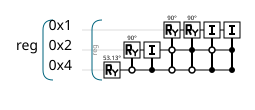

In [2]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)
reg = Qubits(3, "reg", qpu)

usp = UniformStatePrep()
usp.compute(5, reg)

qpu.print_state_vector()
qpu.draw()

You can use one Qubrick instance to call the `compute` method multiple times with different arguments; you don't have to create a new Qubrick instance every time you need its `compute` method.

The following example uses one instance of the `UniformStatePrep` Qubrick to prepare uniform superposition states on two Qubits registers.

|reg1>
|0>    0.447214+0.000000j
|1>    0.447214+0.000000j
|2>    0.447214+0.000000j
|3>    0.447214+0.000000j
|4>    0.447214+0.000000j
|reg2>
|0>    0.577350+0.000000j
|1>    0.577350+0.000000j
|2>    0.577350+0.000000j


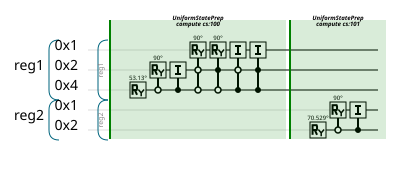

In [3]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=5)
reg1 = Qubits(3, "reg1", qpu)
reg2 = Qubits(2, "reg2", qpu)

usp = UniformStatePrep()
usp.compute(5, reg1)
usp.compute(3, reg2)

reg1.print_state_vector()
reg2.print_state_vector()
qpu.draw(show_qubricks=True)

## Qubrick interchangeability

One of the core design principles of Qubricks is _interchangeability_: if you need to apply a certain routine in your program, you can choose any Qubrick that implements this routine, and you can easily change which Qubrick you use by just changing the class you instantiate in the code. Same as with classical libraries, there can be some differences you need to account for, both in Qubrick method signatures and in their behaviors.

For example, we can swap our implementation of uniform state preparation routine, `UniformStatePrep`, for the `USP` Qubrick from the Workbench library which does the same thing. Its constructor is very similar to that of `UniformStatePrep`, and the signature of the `compute` method is identical, so swapping two Qubricks in the code is very simple. However, the computation implemented by the Qubrick is different: the `qpu.print_state_vector()` output shows that it prepares the state with a complex global phase, and the circuit diagram shows that it uses two extra qubits. The high-level program relying on the Qubrick needs to know about the global phase difference (which might be important when using controlled versions of these two routines!), but it doesn't necessarily need to track the additional qubits used.

|reg|?>
|0|.>    -0.282843+0.346410j
|1|.>    -0.282843+0.346410j
|2|.>    -0.282843+0.346410j
|3|.>    -0.282843+0.346410j
|4|.>    -0.282843+0.346410j


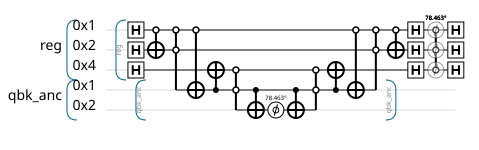

In [4]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.usp import USP

qpu = QPU(num_qubits=5)
reg = Qubits(3, "reg", qpu)

usp = USP()
usp.compute(5, reg)

qpu.print_state_vector()
qpu.draw()

## Returning a value from a Qubrick

Most Qubricks implement quantum routines that don't have a return value; their effect is acting on their qubit arguments. However, some routines can have a classical return value. How can we implement this as a Qubrick?

> We will discuss Qubricks that allocate qubits and return these qubits as a result of their action later, when we dive into quantum memory management in Qubricks.

The `_compute` method of a Qubrick cannot return a value (if it does, it is ignored by the infrastructure that converts it into the `compute` method). Instead, you can call the `set_classical_result` method of the Qubrick class within the `_compute` method to assign an instance variable with the given name and value.

The following example shows how to define a Qubrick which performs a parity measurement on the given Qubits register and returns the classical result ($0$ or $1$). It uses the `ppm()` method, a built-in method of the Qubits class that performs a Pauli product measurement.

In [5]:
from psiqdk.workbench import Qubits, Qubrick

class ParityMeasurement(Qubrick):
    """Qubrick to perform a parity measurement."""
    def _compute(self, reg: Qubits) -> None:
        res = reg.ppm(1, 0, ~0)
        self.set_classical_result(res, "parity")

To apply this routine, you call the `compute` method with the necessary parameters, as usual. After that, you call the `get_classical_result()` method of the Qubrick instance to fetch the value of the instance variable with the given name.

The following code snippet shows how to use the two Qubricks we've defined in this tutorial, `UniformStatePrep` and `ParityMeasurement`, to prepare a three-qubit superposition state and then measure its parity. You will see that the state after the measurement matches the measurement outcome returned by the `ParityMeasurement` Qubrick: it is a uniform superposition of $|0\rangle = |000\rangle$ and $|3\rangle = |110\rangle$ if the parity is $0$, or a uniform superposition of $|1\rangle = |100\rangle$, $|2\rangle = |010\rangle$ and $|4\rangle = |001\rangle$ if the parity is $1$.

|reg>
|0>    0.447214+0.000000j
|1>    0.447214+0.000000j
|2>    0.447214+0.000000j
|3>    0.447214+0.000000j
|4>    0.447214+0.000000j
1
|reg>
|1>    0.577350+0.000000j
|2>    0.577350+0.000000j
|4>    0.577350+0.000000j


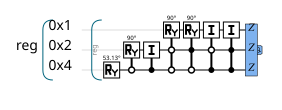

In [6]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)
reg = Qubits(3, "reg", qpu)

usp = UniformStatePrep()
usp.compute(5, reg)

reg.print_state_vector()

pm = ParityMeasurement()
pm.compute(reg)

print(pm.get_classical_result("parity"))
reg.print_state_vector()
qpu.draw()


## Visualizing Qubricks

In the example above, the circuit diagram showed only the low-level representation of the program: the gates applied to the qubits. However, if your program uses Qubricks extensively, it can be convenient to show them on the circuit diagram as well. You can do that by passing `show_qubricks=True` to the `draw()` method of the QPU:

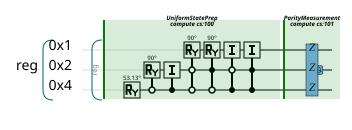

In [7]:
qpu.draw(show_qubricks=True)

## Next steps

In this tutorial, you've learned the basics of defining high-level routines as Workbench Qubricks. The next tutorial will discuss one of the key benefits of using Qubricks in your code - [automatic uncomputation](./Qubricks-Uncomputation.ipynb).